# A full training loop

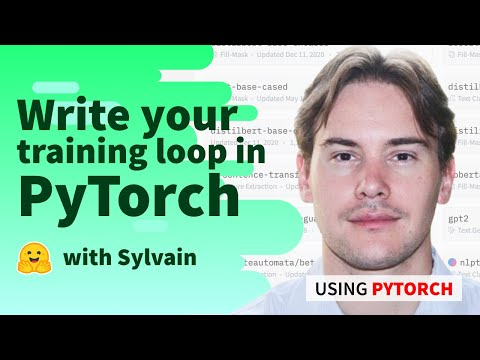

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo("Dh9CL8fyG80", width=800, height=450)

Now we’ll see how to achieve the same results as we did in the last section without using the Trainer class, implementing a training loop from scratch with modern PyTorch best practices. Again, we assume you have done the data processing in section 2. Here is a short summary covering everything you will need:

> 🏗️ Training from Scratch: This section builds on the previous content. For comprehensive guidance on PyTorch training loops and best practices, check out the [🤗 Transformers training documentation](https://huggingface.co/docs/transformers/main/en/training#train-in-native-pytorch) and the [custom training cookbook](https://huggingface.co/learn/cookbook/en/fine_tuning_code_llm_on_single_gpu#model).

In [2]:
from datasets import load_dataset

raw_datasets = load_dataset("nyu-mll/glue", "mrpc")

In [3]:
from transformers import AutoTokenizer

ckpt = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(ckpt)

In [4]:
tokenized_datasets = raw_datasets.map(
    lambda x: tokenizer(x['sentence1'], x['sentence2'], truncation=True), 
    batched=True
)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

In [5]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
    pad_to_multiple_of=8
)

## Prepare for training

Before actually writing our training loop, we will need to define a few objects. The first ones are the dataloaders we will use to iterate over batches. But before we can define those dataloaders, we need to apply a bit of postprocessing to our `tokenized_datasets`, to take care of some things that the `Trainer` did for us automatically. Specifically, we need to:

- Remove the columns corresponding to values the model does not expect (like the `sentence1` and `sentence2` columns).
- Rename the column `label` to `labels` (because the model expects the argument to be named `labels`).
- Set the format of the datasets so they return PyTorch tensors instead of lists.

Our `tokenized_datasets` has one method for each of those steps:

**Remove Columns:**

In [6]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

**Rename Columns:**

In [7]:
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

**Change format to PyTorch:**

In [8]:
tokenized_datasets.set_format("torch")
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

---

Now that this is done, we can easily define our dataloaders:

In [9]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    dataset=tokenized_datasets["train"], 
    shuffle=True, 
    batch_size=8, 
    collate_fn=data_collator
)

eval_dataloader = DataLoader(
    dataset=tokenized_datasets["validation"], 
    batch_size=8, 
    collate_fn=data_collator
)

In [10]:
for batch in train_dataloader:
    for k, varr in batch.items():
        print(f"- {k}: {varr.shape}")
    break

- labels: torch.Size([8])
- input_ids: torch.Size([8, 80])
- token_type_ids: torch.Size([8, 80])
- attention_mask: torch.Size([8, 80])


---

Note that the actual shapes will probably be slightly different for you since we set `shuffle=True` for the training dataloader and we are padding to the maximum length inside the batch.

Now that we’re completely finished with data preprocessing (a satisfying yet elusive goal for any ML practitioner), let’s turn to the model. We instantiate it exactly as we did in the previous section:

In [11]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(ckpt, num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
outputs = model(**batch)

print(outputs.loss, outputs.logits.shape)

tensor(0.6640, grad_fn=<NllLossBackward0>) torch.Size([8, 2])


---

All `🤗 Transformers` models will return the loss when labels are provided, and we also get the logits (two for each input in our batch, so a tensor of size 8 x 2).

We’re almost ready to write our training loop! We’re just missing two things: 

1. Optimizer
2. Learning rate scheduler

Since we are trying to replicate what the Trainer was doing by hand, we will use the same defaults. The optimizer used by the Trainer is AdamW, which is the same as Adam, but with a twist for weight decay regularization (see “Decoupled Weight Decay Regularization” by Ilya Loshchilov and Frank Hutter):

In [13]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=5e-5)

💡 **Modern Optimization Tips:** For even better performance, you can try:


> - **AdamW with weight decay:** `AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)`
> - **8-bit Adam:** Use `bitsandbytes` for `memory-efficient optimization`
> - **Different learning rates:** Lower learning rates `(1e-5 to 3e-5)` often work better for large models


🚀 **Optimization Resources:** Learn more about optimizers and training strategies in the 🤗 Transformers optimization guide.

Finally, the learning rate scheduler used by default is just a linear decay from the maximum value (5e-5) to 0. To properly define it, we need to know the number of training steps we will take, which is the number of epochs we want to run multiplied by the number of training batches (which is the length of our training dataloader). The Trainer uses three epochs by default, so we will follow that:

In [14]:
from transformers import get_scheduler

num_epochs = 3
steps_per_epoch = len(train_dataloader)

num_training_steps = num_epochs * steps_per_epoch

lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

num_training_steps

1377

## The training loop

One last thing: we will want to use the GPU if we have access to one (on a CPU, training might take several hours instead of a couple of minutes). To do this, we define a device we will put our model and our batches on:

In [15]:
import torch

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cpu')

In [16]:
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

---

We are now ready to train! To get some sense of when training will be finished, we add a progress bar over our number of training steps, using the tqdm library:

---

In [17]:
from tqdm.auto import tqdm

# set progress bar:
progress_bar = tqdm(range(num_training_steps))


model.train()
for epoch in range(num_epochs):
    
    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        
        optimizer.zero_grad()
        
        outputs = model(**batch)
        loss = outputs.loss
        
        loss.backward()
        optimizer.step()
        
        lr_scheduler.step()
        progress_bar.update(1)

  0%|          | 0/1377 [00:00<?, ?it/s]

**💡 Modern Training Optimizations:** To make your training loop even more efficient, consider:

> - **Gradient Clipping:** Add `torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)` before `optimizer.step()`
> - **Mixed Precision:** Use `torch.cuda.amp.autocast()` and `GradScaler` for faster training
> - **Gradient Accumulation:** Accumulate gradients over multiple batches to simulate larger batch sizes
> - **Checkpointing:** Save model checkpoints periodically to resume training if interrupted

**🔧 Implementation Guide:** For detailed examples of these optimizations, see the [🤗 Transformers efficient training guide](https://huggingface.co/docs/transformers/main/en/perf_train_gpu_one) and the [range of optimizers](https://huggingface.co/docs/transformers/main/en/optimizers).

You can see that the core of the training loop looks a lot like the one in the introduction. We didn’t ask for any reporting, so this training loop will not tell us anything about how the model fares. We need to add an evaluation loop for that.

## The evaluation loop

As we did earlier, we will use a metric provided by the 🤗 Evaluate library. We’ve already seen the `metric.compute()` method, but metrics can actually accumulate batches for us as we go over the prediction loop with the method `add_batch()`. Once we have accumulated all the batches, we can get the final result with `metric.compute()`. Here’s how to implement all of this in an evaluation loop:

> **📊 Evaluation Best Practices:** For more sophisticated evaluation strategies and metrics, explore the [🤗 Evaluate documentation](https://huggingface.co/docs/evaluate/) and the [comprehensive evaluation cookbook](https://github.com/huggingface/evaluation-guidebook).

In [18]:
import evaluate

metric = evaluate.load("glue", "mrpc")

model.eval()
for batch in eval_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)

    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)
    metric.add_batch(predictions=predictions, references=batch["labels"])

metric.compute()

{'accuracy': 0.8504901960784313, 'f1': 0.8942807625649913}

---

Again, your results will be slightly different because of the randomness in the model head initialization and the data shuffling, but they should be in the same ballpark.

> ✏️ Try it out! Modify the previous training loop to fine-tune your model on the SST-2 dataset.

## Supercharge your training loop with 🤗 Accelerate

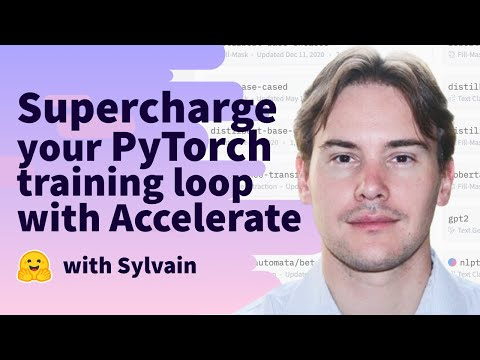

In [19]:
from IPython.display import YouTubeVideo

YouTubeVideo("s7dy8QRgjJ0", width=800, height=450)

The training loop we defined earlier works fine on a single CPU or GPU. But using the [`🤗 Accelerate`](https://github.com/huggingface/accelerate) library, with just a few adjustments we can enable distributed training on multiple GPUs or TPUs. `🤗 Accelerate` handles the complexity of distributed training, mixed precision, and device placement automatically. Starting from the creation of the training and validation dataloaders, here is what our manual training loop looks like:

> ⚡ Accelerate Deep Dive: Learn everything about distributed training, mixed precision, and hardware optimization in the [🤗 Accelerate documentation](https://huggingface.co/docs/accelerate/) and explore practical examples in the [transformers documentation](https://huggingface.co/docs/transformers/main/en/accelerate).

In [21]:
from accelerate import Accelerator
from torch.optim import AdamW

from transformers import AutoModelForSequenceClassification
from transformers import get_scheduler

accelerator = Accelerator()

model = AutoModelForSequenceClassification.from_pretrained(ckpt, num_labels=2)
optimizer = AdamW(model.parameters(), lr=3e-5)

train_dl, eval_dl, model, optimizer = accelerator.prepare(
    train_dataloader, 
    eval_dataloader, 
    model, 
    optimizer
)

num_epochs = 3
num_training_steps = num_epochs * len(train_dl)
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

progress_bar = tqdm(range(num_training_steps))

model.train()
for epoch in range(num_epochs):
    for batch in train_dl:
        outputs = model(**batch)
        loss = outputs.loss
        accelerator.backward(loss)

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  0%|          | 0/1377 [00:00<?, ?it/s]

The first line to add is the import line. The second line instantiates an `Accelerator` object that will look at the environment and initialize the proper distributed setup. 🤗 Accelerate handles the device placement for you, so you can remove the lines that put the model on the device (or, if you prefer, change them to use `accelerator.device` instead of `device`).

Then the main bulk of the work is done in the line that sends the dataloaders, the model, and the optimizer to `accelerator.prepare()`. This will wrap those objects in the proper container to make sure your distributed training works as intended. The remaining changes to make are removing the line that puts the batch on the device (again, if you want to keep this you can just change it to use `accelerator.device`) and replacing `loss.backward()` with `accelerator.backward(loss)`.

> ⚠️ In order to benefit from the speed-up offered by Cloud TPUs, we recommend padding your samples to a fixed length with the padding="max_length" and max_length arguments of the tokenizer.

To try it out in your distributed setup, run the command:

`accelerate config`

which will prompt you to answer a few questions and dump your answers in a configuration file used by this command:

`accelerate launch train.py`

which will launch the distributed training.

If you want to try this in a Notebook (for instance, to test it with TPUs on Colab), just paste the code in a training_function() and run a last cell with:

In [16]:
def training_function(checkpoint, train_dataloader, eval_dataloader, model, optimizer):
    
    from accelerate import Accelerator
    from torch.optim import AdamW
    
    from transformers import AutoModelForSequenceClassification
    from transformers import get_scheduler
    
    accelerator = Accelerator()
    
    model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)
    optimizer = AdamW(model.parameters(), lr=3e-5)
    
    train_dl, eval_dl, model, optimizer = accelerator.prepare(
        train_dataloader, 
        eval_dataloader, 
        model, 
        optimizer
    )
    
    num_epochs = 3
    num_training_steps = num_epochs * len(train_dl)
    lr_scheduler = get_scheduler(
        "linear",
        optimizer=optimizer,
        num_warmup_steps=0,
        num_training_steps=num_training_steps,
    )
    
    progress_bar = tqdm(range(num_training_steps))
    
    model.train()
    for epoch in range(num_epochs):
        for batch in train_dl:
            outputs = model(**batch)
            loss = outputs.loss
            accelerator.backward(loss)
    
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()
            progress_bar.update(1)

In [23]:
from accelerate import notebook_launcher
from tqdm import tqdm

notebook_launcher(
    training_function, 
    (ckpt, train_dataloader, eval_dataloader, model, optimizer), 
    num_processes=0
)

Launching training on MPS.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  0%|              